# Ted Talk Temporal Analysis - Rhetoric

In [2]:
import pandas as pd
import kagglehub
from collections import Counter
import ast
import matplotlib.pyplot as plt

/Users/emilydonofrio/NLaoP/gensim-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Download latest version
path = kagglehub.dataset_download("miguelcorraljr/ted-ultimate-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/emilydonofrio/.cache/kagglehub/datasets/miguelcorraljr/ted-ultimate-dataset/versions/2


In [4]:
data_path = "/2020-05-01/ted_talks_en.csv"

full_path = path + data_path
print(full_path)

/Users/emilydonofrio/.cache/kagglehub/datasets/miguelcorraljr/ted-ultimate-dataset/versions/2/2020-05-01/ted_talks_en.csv


In [5]:
df = pd.read_csv(full_path)
df.shape

(4005, 19)

### Preprocessing

In [6]:
df['recorded_date'] = pd.to_datetime(df['recorded_date'])
df['recorded_date'].max()

Timestamp('2020-04-30 00:00:00')

In [7]:
df['Year'] = df['recorded_date'].dt.year

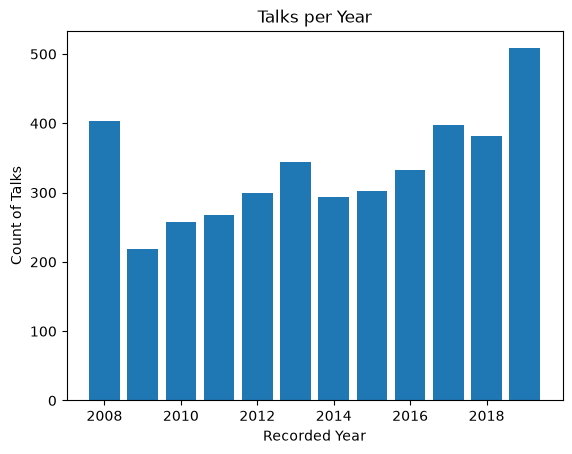

In [8]:
# create year groups
def yeargroup(year):
  if year < 2008:
    return 2008
  if year == 2020:
    return 2019
  return year

df['year_group'] = df['Year'].apply(yeargroup)

# plot count of talks per year
talk_count = df.groupby("year_group")['talk_id'].size().reset_index()

plt.bar(x="year_group", height='talk_id', data=talk_count)
plt.title("Talks per Year")
plt.ylabel("Count of Talks")
plt.xlabel("Recorded Year")
plt.show()

In [9]:
import re

# basic preprocessing and tokenization
# no need to remove stopwords as focusing on specific vocabulary
transcripts = df["transcript"].str.lower()

transcript_tokens = []

for doc in transcripts:
    # keep only letters and spaces
    doc = re.sub(r"[^a-z\s]", " ", doc)

    transcript_tokens.append(doc.split())

## Pronoun Usage

In [10]:
first_person_singular = ["i", "me", "my", "mine", "myself"]
first_person_plural = ["we", "us", "our", "ours", "ourselves"]
second_person = ["you", "your", "yours", "yourself", "yourselves"]

In [11]:
# count occurrences of each pronoun in each transcript
first_person_singular_count = [sum(1 for word in doc if word in first_person_singular) for doc in transcript_tokens]
first_person_plural_count = [sum(1 for word in doc if word in first_person_plural) for doc in transcript_tokens]
second_person_count = [sum(1 for word in doc if word in second_person) for doc in transcript_tokens]

# calculate pronoun rates per 1000 words
total_words = [len(doc) for doc in transcript_tokens]
first_person_singular_rate = [count / max(words, 1) * 1000 for count, words in zip(first_person_singular_count, total_words)]
first_person_plural_rate = [count / max(words, 1) * 1000 for count, words in zip(first_person_plural_count, total_words)]
second_person_rate = [count / max(words, 1) * 1000 for count, words in zip(second_person_count, total_words)]

# create a DataFrame to hold the pronoun rates
pronoun_rates_df = pd.DataFrame({
    "first_person_singular_rate": first_person_singular_rate,
    "first_person_plural_rate": first_person_plural_rate,
    "second_person_rate": second_person_rate
})

print(pronoun_rates_df.head())

   first_person_singular_rate  first_person_plural_rate  second_person_rate
0                   34.029038                 16.333938           23.593466
1                   19.104291                 23.488882           11.901034
2                   37.377803                  4.600345           38.527890
3                   27.839291                 22.461246           10.123379
4                   23.744292                 24.048706           24.048706


In [12]:
pronoun_rates_df.shape

(4005, 3)

In [15]:
pronoun_rates_df['year_group'] = df['year_group']

# group by year and calculate average pronoun rates
average_pronoun_rates = pronoun_rates_df.groupby('year_group').mean()
average_pronoun_rates

,first_person_singular_rate,first_person_plural_rate,second_person_rate
year_group,,,
2008.0,28.811946,17.676146,20.477524
2009.0,23.343978,20.608489,18.334529
2010.0,25.563576,20.819797,18.914495
2011.0,25.896827,20.806967,19.235354
2012.0,25.773004,19.700425,18.844670
2013.0,23.134661,19.182366,18.529046
2014.0,24.012272,19.619035,16.679960
2015.0,22.938537,19.976824,16.075532
2016.0,23.958194,21.869893,16.164752


<Axes: xlabel='year_group'>

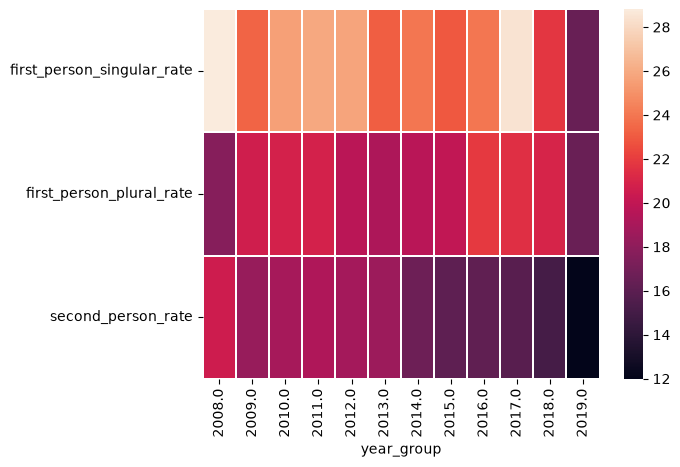

In [16]:
import seaborn as sns
sns.heatmap(
    average_pronoun_rates.T,
    linewidths=.2,
    xticklabels=True,
    yticklabels=True
)

### Comedic talks over time

Audience laughter is recorded in the transcripts as "(laughter)". Can be an indicator of comedic tone

In [20]:
# get example of transcript with "laughter"
laughter_transcripts = [t for t in transcripts if "(laughter)" in t]

print(len(laughter_transcripts))
print(laughter_transcripts[0])

2501
thank you so much, chris. and it's truly a great honor to have the opportunity to come to this stage twice; i'm extremely grateful. i have been blown away by this conference, and i want to thank all of you for the many nice comments about what i had to say the other night. and i say that sincerely, partly because (mock sob) i need that. (laughter) put yourselves in my position. (laughter) i flew on air force two for eight years. (laughter) now i have to take off my shoes or boots to get on an airplane! (laughter) (applause) i'll tell you one quick story to illustrate what that's been like for me. (laughter) it's a true story — every bit of this is true. soon after tipper and i left the — (mock sob) white house — (laughter) we were driving from our home in nashville to a little farm we have 50 miles east of nashville. driving ourselves. (laughter) i know it sounds like a little thing to you, but — (laughter) i looked in the rear-view mirror and all of a sudden it just hit me. there

In [22]:
# count number of "(laughter)" in each transcript
laughter_counts = [t.count("(laughter)") for t in transcripts]

# calculate laughter rates per 1000 words

laughter_rates = [count / max(words, 1) * 1000 for count, words in zip(laughter_counts, total_words)]

# create a DataFrame to hold the laughter counts
laughter_rates_df = pd.DataFrame({
    "laughter_rate": laughter_rates,
    "year_group": df['year_group']
})

# calculate average laughter rates per year group
average_laughter_rates = laughter_rates_df.groupby('year_group').mean()

average_laughter_rates

,laughter_rate
year_group,
2008.0,2.846709
2009.0,1.761665
2010.0,1.879916
2011.0,1.996821
2012.0,2.298730
2013.0,1.311219
2014.0,1.187044
2015.0,1.728485
2016.0,1.857863


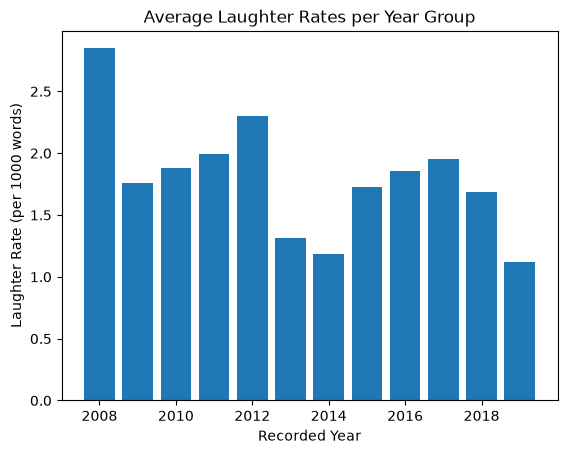

In [23]:
# plot laughter rates over time
plt.bar(x=average_laughter_rates.index, height='laughter_rate', data=average_laughter_rates)
plt.title("Average Laughter Rates per Year Group")
plt.ylabel("Laughter Rate (per 1000 words)")
plt.xlabel("Recorded Year")
plt.show()